In [1]:

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from tqdm import tqdm

from agents.AgentSARSA import AgentSarsa

In [2]:
def plot_success_ratio(list_stats_success):
    successes = np.array(list_stats_success)

    # media acumulada
    cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(cumulative_ratio)
    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.show()


def plot_episode_length(episode_lengths):
    y = np.array(episode_lengths, dtype=float)
    x = np.arange(len(y))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="Steps por episodio")


    plt.title("Taxi SARSA: longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_global_avg(list_stats):
    indices = list(range(len(list_stats)))
    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats)
    plt.title("Taxi SARSA: media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.show()






In [3]:
env = gym.make("Taxi-v3")

n_episodes = 80000
agent = AgentSarsa(
    env,
    epsilon=1.0,
    decay=True,
    discount_factor=0.99,
    alpha=0.1,
    epsilon_min=0.01,
    epsilon_decay=0.9995
)

step_display = n_episodes // 10



for episode in tqdm(range(n_episodes)):
    state, info = env.reset()
    action = agent.get_action(state)

    done = False
    while not done:
        next_state, reward, terminated, truncated, info = env.step(action)

        next_action = agent.update(
            state, action, next_state, reward, terminated, truncated, info
        )

        done = terminated or truncated
        state = next_state

        if not done:
            action = next_action


    if episode % step_display == 0 and episode != 0:
        print(f"avg_return: {agent.stats / (episode + 1):.2f}, epsilon: {agent.epsilon:.4f}")

Q, list_stats, episode_lengths, list_stats_success = agent.get_stats()
env.close()

  0%|          | 0/80000 [00:00<?, ?it/s]

 10%|█         | 8282/80000 [00:09<00:23, 3079.85it/s]

avg_return: -86.47, epsilon: 0.0183


 21%|██        | 16440/80000 [00:12<00:20, 3069.22it/s]

avg_return: -39.57, epsilon: 0.0100


...

 81%|████████  | 64706/80000 [00:27<00:04, 3209.31it/s]

avg_return: -4.34, epsilon: 0.0100


 91%|█████████ | 72511/80000 [00:30<00:02, 3106.23it/s]

avg_return: -3.04, epsilon: 0.0100


100%|██████████| 80000/80000 [00:32<00:00, 2455.07it/s]


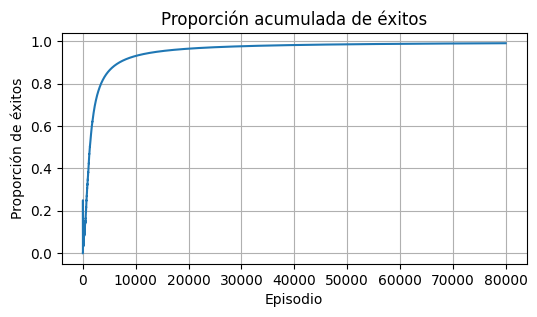

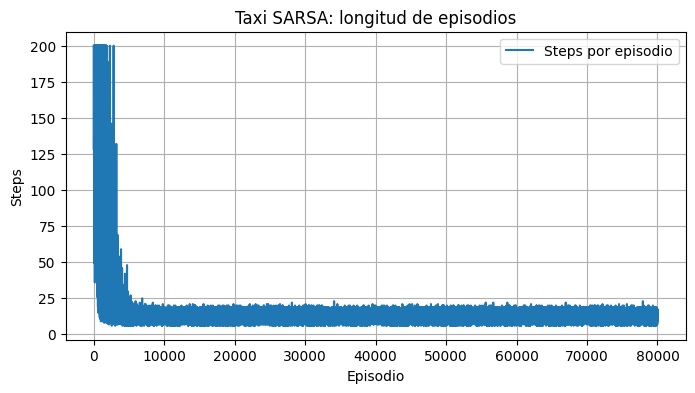

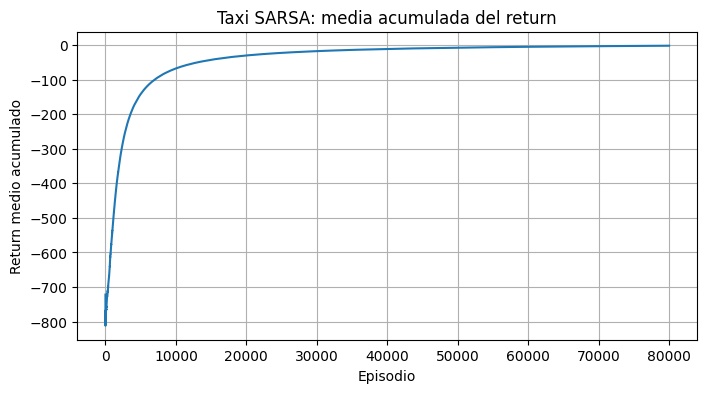

In [4]:


plot_success_ratio(list_stats_success)             # "Proporción de recompensas" (éxito acumulado)
plot_episode_length(episode_lengths)  # Steps por episodio 
plot_global_avg(list_stats)                        # Media acumulada global 